Juegos con año válido: 16327


Year
2011    1139
2012     657
2013     546
2014     582
2015     614
2016     344
2017       3
2020       1
dtype: int64

Años sin ningún registro dentro del periodo: 0
Periodo de análisis: 1980 a 2015
Número de años: 36


Year
2011-01-01    515.99
2012-01-01    363.54
2013-01-01    368.11
2014-01-01    337.05
2015-01-01    264.44
Freq: YS-JAN, Name: Global_Sales, dtype: float64

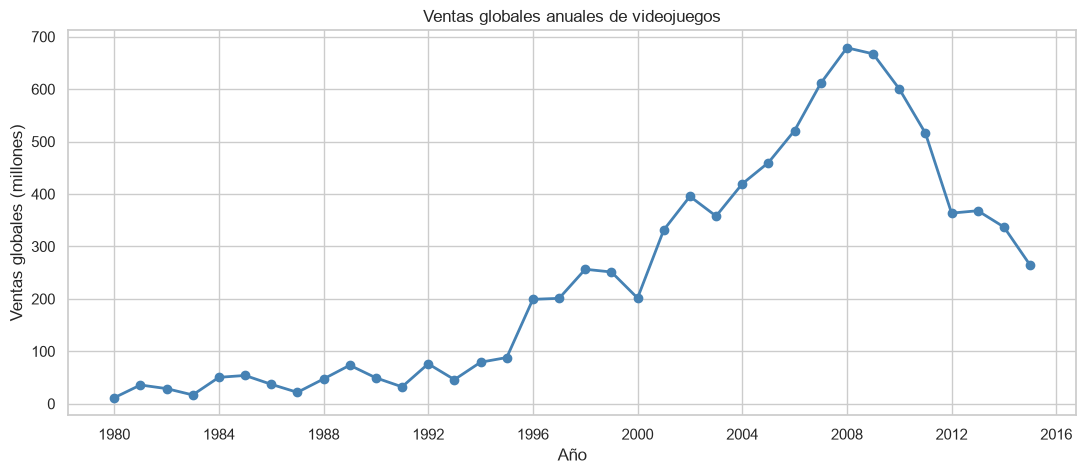

Prueba de estacionariedad Dickey-Fuller aumentada
Estadístico ADF: -1.2645
p-value: 0.6453

La serie no parece estacionaria; se probará diferenciación dentro de ARIMA.
Orígenes evaluados: 2000 a 2012 (13 ventanas de 3 años)


,Modelo,MAE promedio (M),Mejora vs base (%)
0,Modelo base,111.37,0.00
1,Holt amortiguado,111.56,-0.17
2,ARIMA,126.49,-13.58


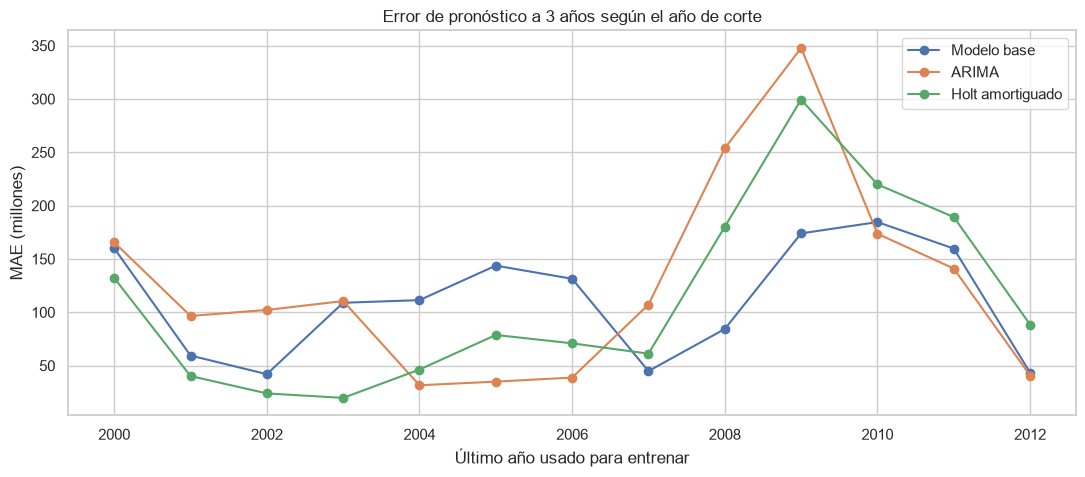

Modelo seleccionado: Holt amortiguado
No supera al modelo base (diferencia de -0.2% en MAE): con esta serie corta, el pronóstico debe tomarse como orientativo.
ARIMA elegido con toda la serie: (0, 1, 2)


,Orden ARIMA,AIC,BIC
0,"(0, 1, 2)",355.133872,359.531080
1,"(1, 1, 2)",356.179943,362.042886
2,"(2, 1, 2)",358.052325,365.381004
3,"(0, 1, 1)",363.235070,366.228085
4,"(1, 1, 1)",364.066680,368.556203


,Año,Ventas pronosticadas (M),Límite inferior,Límite superior
0,2016,233.8,122.3,345.4
1,2017,209.3,97.8,320.9
2,2018,189.7,78.2,301.3


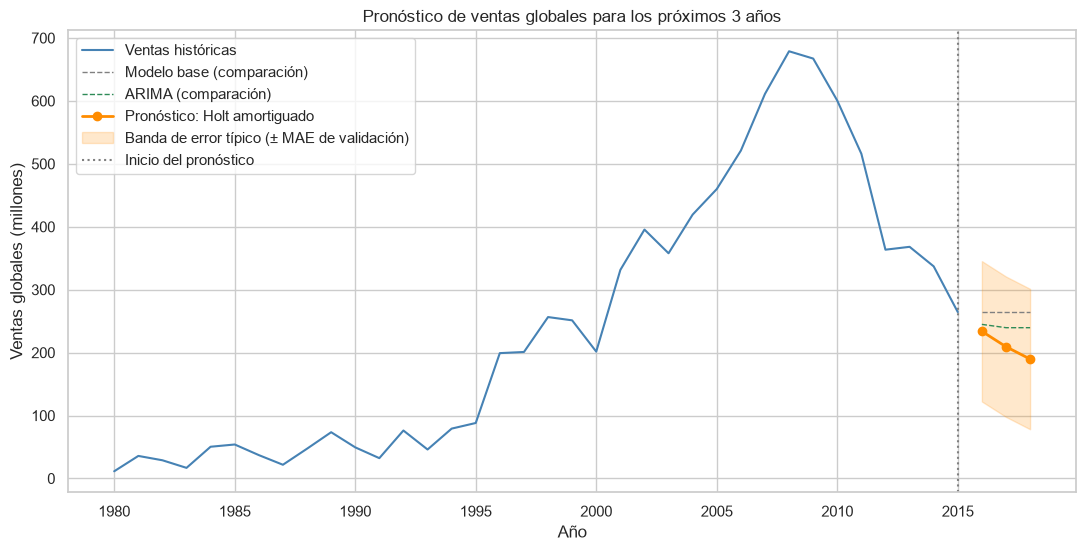


CONCLUSIONES DEL MODELO

La variable objetivo fue Global_Sales (millones de unidades), agregada por año
entre 1980 y 2015.

Validación con origen móvil (13 ventanas de 3 años), MAE promedio:
- Modelo base       -> 111.4
- ARIMA             -> 126.5
- Holt amortiguado  -> 111.6

Modelo final seleccionado: Holt amortiguado.



In [4]:
# %% [markdown]
# # 03 - Forecasting de ventas anuales con ARIMA
# Objetivo: construir, validar y usar un modelo de series de tiempo para pronosticar
# las ventas globales anuales de videojuegos.

# %%
from pathlib import Path
from itertools import product
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RAIZ = Path.cwd().parent
RUTA_DATOS = RAIZ / "data" / "vgsales.csv"
CARPETA_IMG = RAIZ / "images"
CARPETA_IMG.mkdir(exist_ok=True)

def guardar(nombre):
    plt.savefig(CARPETA_IMG / nombre, dpi=150, bbox_inches="tight")

# %%
# CARGAR DATOS
df = pd.read_csv(RUTA_DATOS)
df = df.drop_duplicates()
df = df.dropna(subset=["Year", "Global_Sales"]).copy()
df["Year"] = df["Year"].astype(int)

print("Juegos con año válido:", len(df))

# %%
# DEFINIR HASTA QUÉ AÑO LOS DATOS ESTÁN COMPLETOS
# Igual que con las semanas sin captura al final de una serie, los últimos años del
# dataset tienen muy pocos registros. No significan "se vendió casi cero", sino
# "todavía no hay datos". Si los dejamos, el modelo aprendería una caída falsa.
conteo_anual = df.groupby("Year").size()
display(conteo_anual.tail(8))

ANIO_FINAL = 2015   # 2016 tiene casi la mitad de registros que 2015; 2017 y 2020 casi ninguno

# %%
# CONSTRUIR LA SERIE ANUAL
ventas_anuales = (
    df[df["Year"] <= ANIO_FINAL]
    .groupby("Year")["Global_Sales"]
    .sum()
    .sort_index()
)

# Índice de fechas con frecuencia anual (inicio de año)
ventas_anuales.index = pd.to_datetime(ventas_anuales.index.astype(str), format="%Y")
ventas_anuales = ventas_anuales.asfreq("YS")

huecos = ventas_anuales.isna().sum()
print(f"Años sin ningún registro dentro del periodo: {huecos}")
ventas_anuales = ventas_anuales.fillna(0)
ventas_anuales.name = "Global_Sales"

print(f"Periodo de análisis: {ventas_anuales.index.min().year} a {ventas_anuales.index.max().year}")
print(f"Número de años: {len(ventas_anuales)}")

display(ventas_anuales.tail())

# %%
# EXPLORAR EL COMPORTAMIENTO DE LAS VENTAS
plt.figure(figsize=(13, 5))
plt.plot(ventas_anuales.index, ventas_anuales.values, color="steelblue", linewidth=2, marker="o")
plt.title("Ventas globales anuales de videojuegos")
plt.xlabel("Año")
plt.ylabel("Ventas globales (millones)")
guardar("10_serie_anual.png")
plt.show()

# %%
# PRUEBA DE ESTACIONARIEDAD (Dickey-Fuller aumentada)
resultado_adf = adfuller(ventas_anuales)

print("Prueba de estacionariedad Dickey-Fuller aumentada")
print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
print(f"p-value: {resultado_adf[1]:.4f}")

if resultado_adf[1] < 0.05:
    print("\nLa serie parece estacionaria.")
else:
    print("\nLa serie no parece estacionaria; se probará diferenciación dentro de ARIMA.")

# %% [markdown]
# ## Nota sobre los datos
# El número de juegos registrados cae de ~1,400 por año (2008-2009) a ~600 desde 2012.
# Parte de esa caída puede deberse a menor cobertura del dataset y no solo al mercado,
# así que el pronóstico debe leerse como "ventas registradas en este dataset".

# %% [markdown]
# ## Estrategia de modelado
# - Serie anual y corta (~36 puntos), con auge hasta 2008 y caída posterior.
# - Se comparan 3 modelos: **modelo base** (repite el último valor), **ARIMA** y
#   **Holt amortiguado** (tendencia que se va apagando con el tiempo).
# - En lugar de una sola ventana de prueba (justo la caída posterior al pico, que
#   engaña a cualquier modelo), se usa **validación con origen móvil**: se entrena hasta
#   distintos años, se pronostican los 3 siguientes y se promedia el error.
# - ARIMA: la diferenciación `d` se elige con la prueba ADF (máximo 1) y `p`, `q` por AIC
#   dentro de ese `d`. No se compara AIC entre distintos `d` porque no es comparable, y se
#   evita `d=2`, que con pocos datos solo extrapola la tendencia reciente y sobreajusta.
# - Con `d=0` se incluye constante; sin ella el pronóstico se iría a cero.
# - Se excluye ARIMA(0,d,0): equivale a repetir el último valor (línea recta) y eso ya lo
#   representa el modelo base.

# %%
HORIZONTE = 3          # años a pronosticar (en validación y en el pronóstico final)
ORIGEN_INICIAL = 2000  # primer año hasta el que se entrena en la validación
MODELOS = ["Modelo base", "ARIMA", "Holt amortiguado"]

def indice_futuro(serie, horizonte):
    return pd.date_range(
        start=serie.index.max() + pd.DateOffset(years=1),
        periods=horizonte,
        freq="YS"
    )

def elegir_d(serie, maximo=1):
    """Número de diferenciaciones según ADF (0 o 1)."""
    d = 0
    actual = serie.copy()
    while d < maximo:
        try:
            p_value = adfuller(actual.dropna())[1]
        except Exception:
            p_value = 1.0
        if p_value < 0.05:
            break
        actual = actual.diff().dropna()
        d += 1
    return d

def ajustar_arima(serie, p_max=2, q_max=2):
    """Elige d con ADF y (p, q) con AIC. Devuelve modelo ajustado, orden y tabla de AIC."""
    d = elegir_d(serie)
    tendencia = "c" if d == 0 else None   # con d=0 hace falta constante
    filas, mejor = [], None

    for p, q in product(range(p_max + 1), range(q_max + 1)):
        if p == 0 and q == 0:
            continue   # ARIMA(0,d,0) es solo un caminante aleatorio: ya lo cubre el modelo base
        try:
            ajuste = SARIMAX(
                serie,
                order=(p, d, q),
                trend=tendencia,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
        except Exception:
            continue

        filas.append({"Orden ARIMA": (p, d, q), "AIC": ajuste.aic, "BIC": ajuste.bic})
        if mejor is None or ajuste.aic < mejor[0]:
            mejor = (ajuste.aic, (p, d, q), ajuste)

    if mejor is None:
        raise ValueError("No se pudo ajustar ningún ARIMA")

    tabla = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
    return mejor[2], mejor[1], tabla

def pronosticar(nombre, serie, horizonte):
    """Pronostica `horizonte` años con el modelo indicado."""
    futuro = indice_futuro(serie, horizonte)

    if nombre == "Modelo base":
        pred = pd.Series(serie.iloc[-1], index=futuro)

    elif nombre == "ARIMA":
        ajuste, _, _ = ajustar_arima(serie)
        pred = ajuste.get_forecast(steps=horizonte).predicted_mean
        pred.index = futuro

    elif nombre == "Holt amortiguado":
        ajuste = ExponentialSmoothing(
            serie, trend="add", damped_trend=True, initialization_method="estimated"
        ).fit()
        pred = ajuste.forecast(horizonte)
        pred.index = futuro

    return pred.astype(float)

# %%
# VALIDACIÓN CON ORIGEN MÓVIL
ultimo_origen = ventas_anuales.index.max().year - HORIZONTE
errores = {m: [] for m in MODELOS}
origenes = list(range(ORIGEN_INICIAL, ultimo_origen + 1))

for origen in origenes:
    corte = pd.Timestamp(year=origen, month=1, day=1)
    entreno = ventas_anuales.loc[:corte]
    real = ventas_anuales.loc[corte + pd.DateOffset(years=1):].iloc[:HORIZONTE]

    for nombre in MODELOS:
        try:
            pred = pronosticar(nombre, entreno, HORIZONTE)
        except Exception:
            pred = pronosticar("Modelo base", entreno, HORIZONTE)   # respaldo si falla el ajuste
        pred = pred.clip(lower=0)
        errores[nombre].append(mean_absolute_error(real.values, pred.values))

print(f"Orígenes evaluados: {origenes[0]} a {origenes[-1]} ({len(origenes)} ventanas de {HORIZONTE} años)")

# %%
# COMPARAR MODELOS
mae_promedio = {m: np.mean(errores[m]) for m in MODELOS}

comparacion_modelos = pd.DataFrame({
    "Modelo": MODELOS,
    "MAE promedio (M)": [mae_promedio[m] for m in MODELOS],
    "Mejora vs base (%)": [(1 - mae_promedio[m] / mae_promedio["Modelo base"]) * 100 for m in MODELOS]
}).sort_values("MAE promedio (M)").reset_index(drop=True)
display(comparacion_modelos.round(2))

plt.figure(figsize=(13, 5))
for nombre in MODELOS:
    plt.plot(origenes, errores[nombre], marker="o", label=nombre)
plt.title(f"Error de pronóstico a {HORIZONTE} años según el año de corte")
plt.xlabel("Último año usado para entrenar")
plt.ylabel("MAE (millones)")
plt.legend()
guardar("11_validacion_modelos.png")
plt.show()

# %%
# ELEGIR EL MODELO FINAL
# El modelo base es solo la vara para medir: el modelo final sale de entre ARIMA y Holt.
candidatos = ["ARIMA", "Holt amortiguado"]
modelo_ganador = min(candidatos, key=lambda m: mae_promedio[m])

mejora = (1 - mae_promedio[modelo_ganador] / mae_promedio["Modelo base"]) * 100
print(f"Modelo seleccionado: {modelo_ganador}")
if mejora > 0:
    print(f"Supera al modelo base en {mejora:.1f}% de MAE.")
else:
    print(f"No supera al modelo base (diferencia de {mejora:.1f}% en MAE): "
          "con esta serie corta, el pronóstico debe tomarse como orientativo.")

# %%
# AJUSTE FINAL CON TODA LA SERIE
ajuste_final, orden_final, tabla_aic = ajustar_arima(ventas_anuales)
print(f"ARIMA elegido con toda la serie: {orden_final}")
display(tabla_aic.head(5))

pronosticos = {m: pronosticar(m, ventas_anuales, HORIZONTE) for m in MODELOS}

# Se avisa si el recorte a 0 está ocultando valores negativos
for nombre, pred in pronosticos.items():
    negativos = (pred < 0).sum()
    if negativos > 0:
        print(f"Aviso: {nombre} produjo {negativos} valor(es) negativo(s); se recortan a 0.")
    pronosticos[nombre] = pred.clip(lower=0)

pronostico_futuro = pronosticos[modelo_ganador]

# Banda de error típico: ± el MAE promedio de la validación
banda = mae_promedio[modelo_ganador]
limite_inferior = (pronostico_futuro - banda).clip(lower=0)
limite_superior = pronostico_futuro + banda

tabla_pronostico = pd.DataFrame({
    "Año": pronostico_futuro.index.year,
    "Ventas pronosticadas (M)": pronostico_futuro.values,
    "Límite inferior": limite_inferior.values,
    "Límite superior": limite_superior.values
})
display(tabla_pronostico.round(1))

# %%
# GRÁFICO DEL PRONÓSTICO FUTURO
plt.figure(figsize=(13, 6))
plt.plot(ventas_anuales.index, ventas_anuales.values, label="Ventas históricas", color="steelblue")

for nombre, color in [("Modelo base", "gray"), ("ARIMA", "seagreen"), ("Holt amortiguado", "purple")]:
    if nombre != modelo_ganador:
        plt.plot(pronosticos[nombre].index, pronosticos[nombre].values,
                 linestyle="--", linewidth=1, color=color, label=f"{nombre} (comparación)")

plt.plot(pronostico_futuro.index, pronostico_futuro.values,
         label=f"Pronóstico: {modelo_ganador}", color="darkorange", marker="o", linewidth=2)
plt.fill_between(
    pronostico_futuro.index, limite_inferior, limite_superior,
    color="darkorange", alpha=0.2, label="Banda de error típico (± MAE de validación)"
)

plt.axvline(ventas_anuales.index.max(), color="gray", linestyle=":", label="Inicio del pronóstico")
plt.title(f"Pronóstico de ventas globales para los próximos {HORIZONTE} años")
plt.xlabel("Año")
plt.ylabel("Ventas globales (millones)")
plt.legend()
guardar("12_pronostico_futuro.png")
plt.show()

# %%
print(f"""
CONCLUSIONES DEL MODELO

La variable objetivo fue Global_Sales (millones de unidades), agregada por año
entre {ventas_anuales.index.min().year} y {ventas_anuales.index.max().year}.

Validación con origen móvil ({len(origenes)} ventanas de {HORIZONTE} años), MAE promedio:
- Modelo base       -> {mae_promedio["Modelo base"]:,.1f}
- ARIMA             -> {mae_promedio["ARIMA"]:,.1f}
- Holt amortiguado  -> {mae_promedio["Holt amortiguado"]:,.1f}

Modelo final seleccionado: {modelo_ganador}.
""")